In [1]:
!pip install --upgrade ipython jupyter
!pip install -U bitsandbytes>=0.46.1
%load_ext autoreload
%autoreload 2

def refresh_repo():
    %cd /kaggle/working
    %rm -rf from-neurons-to-directions
    !git clone https://github.com/jefri021/from-neurons-to-directions.git
    %cd /kaggle/working/from-neurons-to-directions/
    !git pull origin main

refresh_repo()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.8/627.8 kB 12.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.14.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
ERROR: pip's dependency resolver does not currentl

In [2]:
import sys
sys.path.insert(0, "/kaggle/working/from-neurons-to-directions/src")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from model_utils import (
    load_model_and_tokenizer,
    apply_chat_template,
    get_num_layers,
    generate,
)
from activation_store import ActivationStore
from refusal_direction import (
    compute_refusal_direction,
    generate_with_ablation,
    generate_with_addition,
)
from safety_neurons import (
    get_top_safety_neurons,
    collect_activations_with_neuron_ablation,
    generate_with_neuron_ablation,
)
from metrics import (
    refusal_rate,
    direction_alignment,
    cosine_similarity_1d,
)
from viz import (
    plot_direction_survival,
    plot_refusal_rates,
    plot_layer_alignment,
)

print("Imports OK")

Imports OK


In [3]:
directions  = torch.load("/kaggle/working/from-neurons-to-directions/data/directions.pt",       map_location="cpu")
best_data   = torch.load("/kaggle/working/from-neurons-to-directions/data/best_direction.pt",   map_location="cpu")
scores      = torch.load("/kaggle/working/from-neurons-to-directions/data/change_scores.pt",    map_location="cpu")
harmful_acts_ablated = torch.load("/kaggle/working/from-neurons-to-directions/data/harmful_residual_ablated.pt",    map_location="cpu")
harmless_acts_ablated = torch.load("/kaggle/working/from-neurons-to-directions/data/harmless_residual_ablated.pt",    map_location="cpu")

best_layer  = best_data["layer"]
best_r      = best_data["direction"]

print(f"Directions loaded : {len(directions)} layers")
print(f"Best layer        : {best_layer}")
print(f"Best r norm       : {best_r.norm():.4f}")

Directions loaded : 812 layers
Best layer        : 16
Best r norm       : 62.4757


In [4]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

model, tokenizer = load_model_and_tokenizer("qwen_instruct")
n_layers = get_num_layers(model)

hf_token = UserSecretsClient().get_secret("HF-READ")

harmful_ds = load_dataset("walledai/AdvBench", token=hf_token)
harmless_ds = load_dataset("tatsu-lab/alpaca", token=hf_token)

harmful = harmful_ds["train"]
harmless = harmless_ds["train"]

harmful_prompts_raw = harmful["prompt"]

# Keep only Alpaca samples with empty input field
harmless_prompts_raw = [
    instruction
    for instruction, inp in zip(harmless["instruction"], harmless["input"])
    if inp.strip() == ""
]

n = min(len(harmful_prompts_raw), len(harmless_prompts_raw))

harmful_prompts_raw = harmful_prompts_raw[:n]
harmless_prompts_raw = harmless_prompts_raw[:n]

print(f"Harmful prompts  : {len(harmful_prompts_raw)}")
print(f"Harmless prompts : {len(harmless_prompts_raw)}")

harmful_prompts  = [apply_chat_template(p, tokenizer) for p in harmful_prompts_raw]
harmless_prompts = [apply_chat_template(p, tokenizer) for p in harmless_prompts_raw]

top_neurons = get_top_safety_neurons(scores, k=500)
print(f"\nTop-500 safety neurons ready.")

cand_layers = [best_layer]

Loading 'qwen_instruct' from /kaggle/input/models/qwen-lm/qwen2.5/transformers/7b-instruct/1 ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  7.6B parameters | devices: {'cuda:0', 'cuda:1'}


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.1k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/520 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Harmful prompts  : 520
Harmless prompts : 520
Top-500 safety neurons selected.
  Layer distribution (top 10 layers by count): {17: 167, 16: 107, 15: 96, 14: 77, 13: 53}

Top-500 safety neurons ready.


## 4. Collect residual stream activations — WITH neuron ablation

This is the key intervention of Experiment 2.

We run the same prompts through the instruct model, but with the
safety neurons zeroed out during the forward pass. The residual stream
activations we capture reflect what the model "thinks" after safety
neurons have been silenced.

We then recompute r from these ablated activations and compare to
the original r.

In [5]:
# print("Collecting residual stream activations WITH safety neurons ablated...")
# print("(This runs two sets of forward passes — takes ~10 minutes)\n")

# # Harmful prompts — ablated
# harmful_acts_ablated = collect_activations_with_neuron_ablation(
#     model=model,
#     tokenizer=tokenizer,
#     prompts=harmful_prompts,
#     safety_neurons=top_neurons,
#     layers=cand_layers,
# )

# # Harmless prompts — ablated
# harmless_acts_ablated = collect_activations_with_neuron_ablation(
#     model=model,
#     tokenizer=tokenizer,
#     prompts=harmless_prompts,
#     safety_neurons=top_neurons,
#     layers=cand_layers,
# )

# torch.save(harmful_acts_ablated,
#            "/kaggle/working/from-neurons-to-directions/harmful_residual_ablated.pt")
# torch.save(harmless_acts_ablated,
#            "/kaggle/working/from-neurons-to-directions/harmless_residual_ablated.pt")
# print("Ablated activations saved.")

## 5. Recompute refusal direction from ablated activations

If safety neurons are the source of r, then the refusal direction
computed from ablated activations should be:
  - Weaker (lower norm) — less signal
  - Misaligned with the original r (different direction)

If r survives ablation with high cosine similarity to the original,
it means r is generated by something other than safety neurons.

In [6]:
directions_ablated = compute_refusal_direction(
    harmful_acts_ablated, harmless_acts_ablated, normalize=True
)

print(f"Ablated directions computed for {len(directions_ablated)} layers.")

# Per-layer cosine similarity: original r vs ablated r
sims_original = {l: 1.0 for l in directions}          # original vs itself = 1
sims_ablated  = direction_alignment(directions, directions_ablated)

print(f"\nPer-layer cosine similarity (original r vs ablated r):")
print(f"{'Layer':<8} {'Cosine sim':>12}  {'Interpretation'}")
print("-" * 55)
print(sims_ablated)
for layer_pos in sorted(sims_ablated.keys()):
    sim = sims_ablated[layer_pos]
    interp = ("strong survival" if sim > 0.8
              else "partial survival" if sim > 0.4
              else "largely destroyed")
    print(f"{layer_pos} {sim:>12.4f}  {interp}")

torch.save(sims_ablated,
           "/kaggle/working/from-neurons-to-directions/direction_survival.pt")
print("\nSaved → results/direction_survival.pt")

Computed directions for 1 (layer, position) pairs.
Ablated directions computed for 1 layers.

Per-layer cosine similarity (original r vs ablated r):
Layer      Cosine sim  Interpretation
-------------------------------------------------------
{(16, -1): 0.043681979179382324}
(16, -1)       0.0437  largely destroyed

Saved → results/direction_survival.pt


## 6. Visualize direction survival

This is the central plot of Experiment 2.

Each bar shows how similar the refusal direction is to the original
after safety neurons are ablated. A drop indicates those neurons
were contributing to the direction at that layer.

Saved → /kaggle/working/from-neurons-to-directions/figures/exp2_direction_survival.png


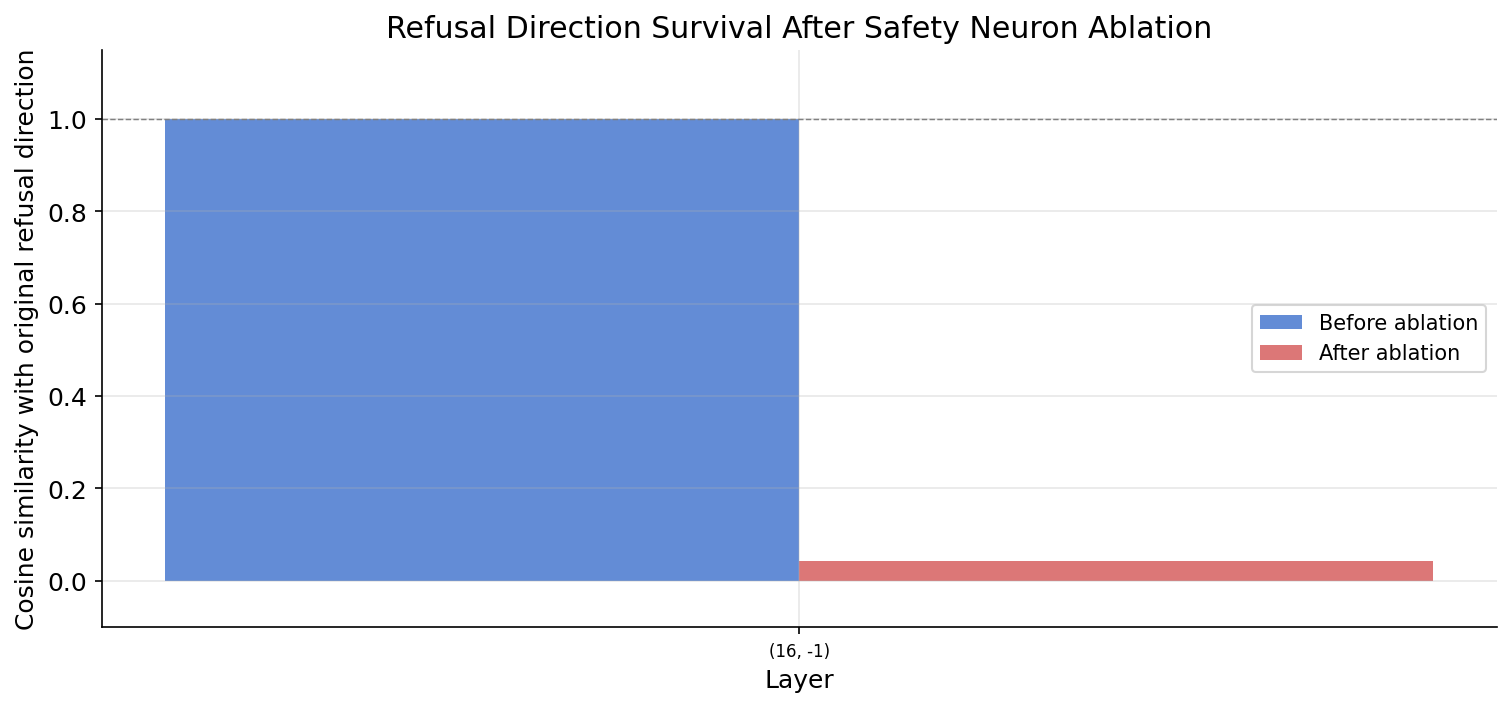

Saved → /kaggle/working/from-neurons-to-directions/figures/exp2_alignment_line.png


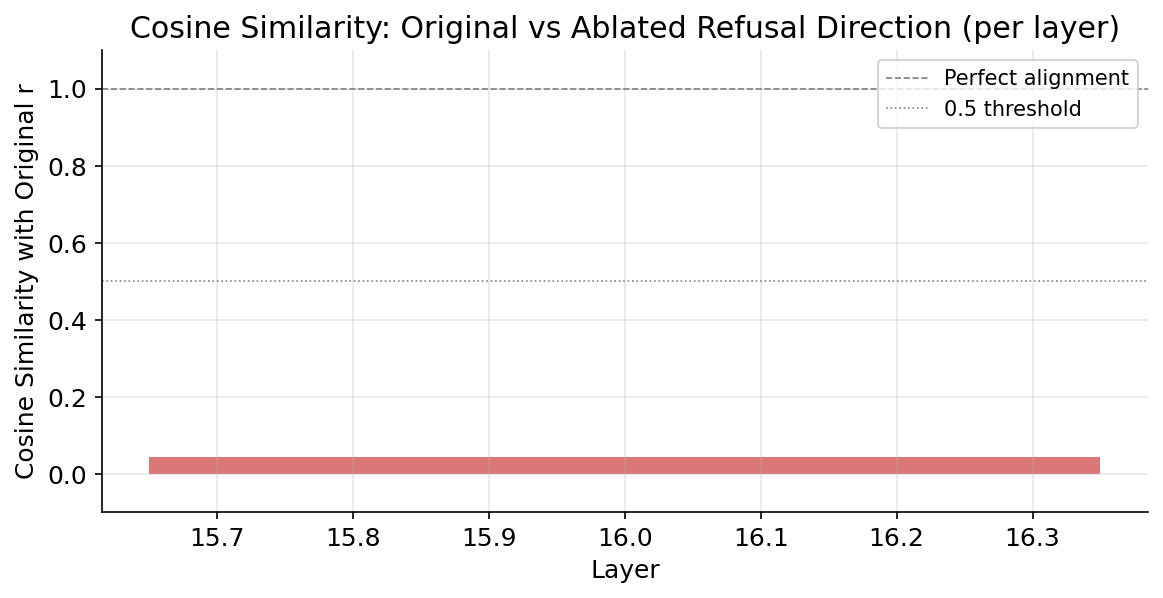

In [7]:
fig = plot_direction_survival(
    original_sims=sims_original,
    ablated_sims=sims_ablated,
    title="Refusal Direction Survival After Safety Neuron Ablation",
    save_path="/kaggle/working/from-neurons-to-directions/figures/exp2_direction_survival.png",
)
plt.show()

sims_ablated_layer_only = {}

for layer_pos, val in sims_ablated.items():
    layer, pos = layer_pos
    if pos == -1:
        sims_ablated_layer_only[layer] = val

# Focused plot: just the ablated similarities as a line
fig2 = plot_layer_alignment(
    similarities=sims_ablated_layer_only,
    title="Cosine Similarity: Original vs Ablated Refusal Direction (per layer)",
    ylabel="Cosine Similarity with Original r",
    save_path="/kaggle/working/from-neurons-to-directions/figures/exp2_alignment_line.png",
)
plt.show()

## 7. Behavioral consequence: neuron ablation vs direction ablation

We now compare three conditions behaviorally on harmful prompts:

  A. Baseline (no intervention)
  B. Direction ablated (Paper 1 method, notebook 01)
  C. Safety neurons ablated (Paper 2 method)
  D. Both ablated simultaneously

If A and B/C produce similar refusal rates, the two interventions
are functionally equivalent — strong evidence for a shared mechanism.
If B and C differ substantially, they're dissociable.

Condition D: Both ablated...

Behavioral results:
  A — Baseline                        : 100%
  B — Direction ablated (Paper 1)     : 0%
  C — Neurons ablated   (Paper 2)     : 93%
  D — Both ablated                    : 0%
Saved → /kaggle/working/from-neurons-to-directions/figures/exp2_behavioral.png


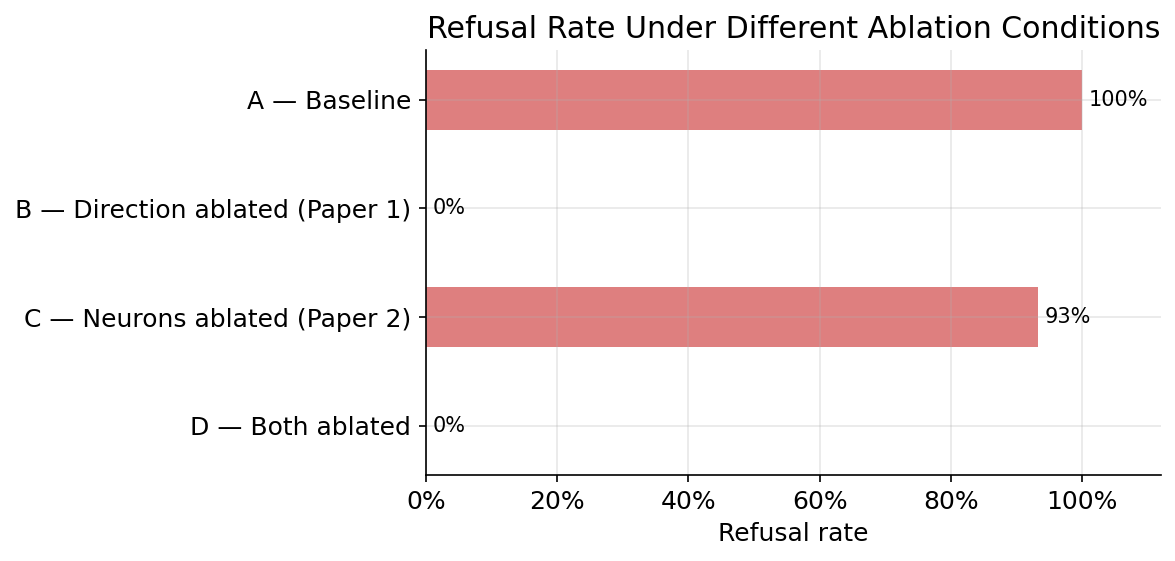

In [12]:
# print("Running behavioral comparison across conditions...\n")

# test_prompts = harmful_prompts[:15]

# # A: Baseline
# print("Condition A: Baseline...")
# baseline_responses = generate(model, tokenizer, test_prompts, max_new_tokens=80)
# rate_A = refusal_rate(baseline_responses)

# # B: Direction ablated only (Paper 1)
# print("Condition B: Direction ablated...")
# dir_ablated_responses = generate_with_ablation(
#     model, tokenizer, test_prompts, best_r, max_new_tokens=80
# )
# rate_B = refusal_rate(dir_ablated_responses)

# # C: Safety neurons ablated only (Paper 2)
# print("Condition C: Neurons ablated...")
# neuron_ablated_responses = generate_with_neuron_ablation(
#     model, tokenizer, test_prompts, top_neurons, max_new_tokens=80
# )
# rate_C = refusal_rate(neuron_ablated_responses)

# D: Both ablated simultaneously
# We do this by registering neuron ablation hooks AND direction ablation hooks
# The direction ablation hook is already handled by generate_with_ablation,
# but we need to add neuron ablation on top.
# Cleanest approach: manual hook stacking
print("Condition D: Both ablated...")

from model_utils import HookManager
from refusal_direction import ablate_direction

hook_handles_D = []
neurons_by_layer = {}
for layer_idx, neuron_idx in top_neurons:
    neurons_by_layer.setdefault(layer_idx, []).append(neuron_idx)

# Neuron ablation pre-hooks
for layer_idx, neuron_indices in neurons_by_layer.items():
    mlp = model.model.layers[layer_idx].mlp
    def make_neuron_hook(n_idx):
        def hook(module, input):
            patched = input[0].clone()
            patched[:, :, n_idx] = 0.0
            return (patched,)
        return hook
    h = mlp.down_proj.register_forward_pre_hook(make_neuron_hook(neuron_indices))
    hook_handles_D.append(h)

# Direction ablation post-hook at ALL layers
def ablation_hook(module, input, output):
    # Apply to the full hidden state: [batch, seq_len, hidden_size]
    hidden = output[0] if isinstance(output, tuple) else output
    hidden = ablate_direction(hidden, best_r)
    if isinstance(output, tuple):
        return (hidden,) + output[1:]
    return hidden

# Register on ALL layers
for layer in model.model.layers:
    handle = layer.register_forward_hook(ablation_hook)
    hook_handles_D.append(handle)

try:
    both_ablated_responses = generate(model, tokenizer, test_prompts, max_new_tokens=80)
    rate_D = refusal_rate(both_ablated_responses)
finally:
    for h in hook_handles_D:
        h.remove()

print(f"\nBehavioral results:")
print(f"  A — Baseline                        : {rate_A:.0%}")
print(f"  B — Direction ablated (Paper 1)     : {rate_B:.0%}")
print(f"  C — Neurons ablated   (Paper 2)     : {rate_C:.0%}")
print(f"  D — Both ablated                    : {rate_D:.0%}")

fig = plot_refusal_rates(
    conditions={
        "A — Baseline":                     rate_A,
        "B — Direction ablated (Paper 1)":  rate_B,
        "C — Neurons ablated (Paper 2)":    rate_C,
        "D — Both ablated":                 rate_D,
    },
    title="Refusal Rate Under Different Ablation Conditions",
    save_path="/kaggle/working/from-neurons-to-directions/figures/exp2_behavioral.png",
)
plt.show()

torch.save({"A": rate_A, "B": rate_B, "C": rate_C, "D": rate_D},
           "/kaggle/working/from-neurons-to-directions/behavioral_comparison.pt")

## 8. Inject r into neuron-ablated model

Final test — Paper 1's activation addition applied to a model
where safety neurons are already ablated.

This probes the causal order: does the refusal direction r work
independently of safety neurons, or does it need them to function?

If injecting r RESTORES refusal even after neuron ablation:
  → r is upstream or parallel to safety neurons
  → direction injection bypasses the neuron-level mechanism

If injecting r FAILS to restore refusal after neuron ablation:
  → safety neurons are necessary for r to take effect
  → the neuron mechanism is downstream of the direction

In [15]:
print("Testing: inject r into neuron-ablated model (harmless prompts)...\n")

hook_handles_E = []

# Neuron ablation pre-hooks (same as condition C)
for layer_idx, neuron_indices in neurons_by_layer.items():
    mlp = model.model.layers[layer_idx].mlp
    def make_neuron_hook(n_idx):
        def hook(module, input):
            patched = input[0].clone()
            patched[:, :, n_idx] = 0.0
            return (patched,)
        return hook
    h = mlp.down_proj.register_forward_pre_hook(make_neuron_hook(neuron_indices))
    hook_handles_E.append(h)

# Direction ADDITION post-hook at ALL layers (instead of ablation)
from refusal_direction import add_direction
layer = model.model.layers[best_layer]
def add_hook(module, input, output):
    hidden = output[0] if isinstance(output, tuple) else output
    hidden = add_direction(hidden, best_r, alpha=50.0)
    return hidden
h = layer.register_forward_hook(add_hook)
hook_handles_E.append(h)

try:
    injection_responses = generate(
        model, tokenizer, harmless_prompts[:15], max_new_tokens=80
    )
    rate_E = refusal_rate(injection_responses)
finally:
    for h in hook_handles_E:
        h.remove()

# Baseline: inject r WITHOUT neuron ablation (from notebook 01)
# We rerun it here for a fair same-session comparison
rate_injection_only = refusal_rate(
    generate_with_addition(model, tokenizer, harmless_prompts[:15],
                           best_r, best_layer, alpha=20.0, max_new_tokens=80)
)

print(f"Refusal rate — r injection only (harmless prompts)     : {rate_injection_only:.0%}")
print(f"Refusal rate — r injection + neuron ablation           : {rate_E:.0%}")
print(f"Delta                                                  : "
      f"{rate_E - rate_injection_only:+.0%}")

if abs(rate_E - rate_injection_only) < 0.10:
    print("\nInterpretation: r injection works independently of safety neurons.")
    print("Direction and neurons are parallel/independent mechanisms.")
else:
    print("\nInterpretation: neuron ablation interferes with r injection.")
    print("Safety neurons are necessary for the direction to take effect.")

torch.save({"injection_only": rate_injection_only, "injection_plus_ablation": rate_E},
           "/kaggle/working/from-neurons-to-directions/injection_test.pt")

Testing: inject r into neuron-ablated model (harmless prompts)...

Refusal rate — r injection only (harmless prompts)     : 13%
Refusal rate — r injection + neuron ablation           : 100%
Delta                                                  : +87%

Interpretation: neuron ablation interferes with r injection.
Safety neurons are necessary for the direction to take effect.


In [16]:
print("=" * 60)
print("EXPERIMENT 2 — CAUSAL BRIDGE SUMMARY")
print("=" * 60)

mean_sim = sum(sims_ablated.values()) / len(sims_ablated)
sim_at_best = sims_ablated.get(best_layer, float("nan"))

print(f"\nRefusal direction survival after neuron ablation:")
print(f"  Mean cosine sim across all layers  : {mean_sim:.4f}")
print(f"  Cosine sim at best layer ({best_layer})     : {sim_at_best:.4f}")

print(f"\nBehavioral comparison (refusal rate):")
print(f"  A — Baseline                       : {rate_A:.0%}")
print(f"  B — Direction ablated              : {rate_B:.0%}")
print(f"  C — Neurons ablated                : {rate_C:.0%}")
print(f"  D — Both ablated                   : {rate_D:.0%}")

print(f"\nDirection injection test (harmless prompts):")
print(f"  r injection only                   : {rate_injection_only:.0%}")
print(f"  r injection + neuron ablation      : {rate_E:.0%}")

print(f"\nConclusion:")
if sim_at_best < 0.4 and abs(rate_B - rate_C) < 0.15:
    print("  Safety neurons causally generate r. The mechanisms are unified.")
elif sim_at_best > 0.7 and abs(rate_B - rate_C) > 0.2:
    print("  r survives neuron ablation. The mechanisms are dissociable.")
else:
    print("  Partial overlap. Safety neurons contribute to but don't fully")
    print("  explain the refusal direction.")

print("=" * 60)
print("\nFiles saved:")
print("  results/direction_survival.pt")
print("  results/behavioral_comparison.pt")
print("  results/injection_test.pt")
print("  results/figures/exp2_direction_survival.png")
print("  results/figures/exp2_alignment_line.png")
print("  results/figures/exp2_behavioral.png")
print("\nNext: run 05_exp3_injection.ipynb")

EXPERIMENT 2 — CAUSAL BRIDGE SUMMARY

Refusal direction survival after neuron ablation:
  Mean cosine sim across all layers  : 0.0437
  Cosine sim at best layer (16)     : nan

Behavioral comparison (refusal rate):
  A — Baseline                       : 100%
  B — Direction ablated              : 0%
  C — Neurons ablated                : 93%
  D — Both ablated                   : 0%

Direction injection test (harmless prompts):
  r injection only                   : 13%
  r injection + neuron ablation      : 100%

Conclusion:
  Partial overlap. Safety neurons contribute to but don't fully
  explain the refusal direction.

Files saved:
  results/direction_survival.pt
  results/behavioral_comparison.pt
  results/injection_test.pt
  results/figures/exp2_direction_survival.png
  results/figures/exp2_alignment_line.png
  results/figures/exp2_behavioral.png

Next: run 05_exp3_injection.ipynb
